# Steam Game Reviews

## Notebook 02 — Feature engineering and word-level semantic analysis

### Scope

This notebook studies classical word-level representations built from the cleaned
review sample prepared in notebook 01: sparse TF-IDF features and dense Word2Vec
embeddings. It also inspects vocabulary, nearest neighbours and two-dimensional
projections.

### Key assumptions

- Word-level analyses use `clean_review`, not the near-raw transformer text.
- TF-IDF and Word2Vec here are descriptive artefacts; notebook 03 evaluates
  document-level representations on the canonical 120,000-review game-grouped split.
- PCA and t-SNE are visual aids, not evidence of model quality.

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from gensim.models import Word2Vec

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import joblib

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

plt.style.use("ggplot")

os.makedirs("outputs/embeddings", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)


## 1. Setup and load the prepared dataset

The dataset generated during the preprocessing stage is loaded and inspected before feature extraction.

In [2]:
df = pd.read_csv("outputs/prepared_reviews_sample.csv")

print(f"Dataset shape: {df.shape}")

display(df.head())


Dataset shape: (100175, 9)


,game_name,recommendation,target,review,clean_review,review_length_words,hours_played,date,language
0,"Warhammer 40,000: Space Marine 2",Recommended,1,The game itself is also super fun. The PvP and...,game also super fun pvp campaign joy play acti...,117,39.9,14 September,en
1,"Warhammer 40,000: Space Marine 2",Recommended,1,Never cared much about Warhammer until this ga...,never cared much warhammer game showed error w...,239,91.5,13 September,en
2,"Warhammer 40,000: Space Marine 2",Recommended,1,A salute to all the fallen battle brothers who...,salute fallen battle brothers years waiting ga...,126,43.3,14 September,en
3,"Warhammer 40,000: Space Marine 2",Recommended,1,this game feels like it was made in the mid 20...,game feels like made mid early like good way,18,16.8,14 September,en
4,"Warhammer 40,000: Space Marine 2",Recommended,1,Reminds me of something I've lost. A genuine g...,reminds something lost genuine game good game ...,19,24.0,12 September,en


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100175 entries, 0 to 100174
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   game_name            100175 non-null  object
 1   recommendation       100175 non-null  object
 2   target               100175 non-null  int64 
 3   review               100175 non-null  object
 4   clean_review         100175 non-null  object
 5   review_length_words  100175 non-null  int64 
 6   hours_played         100175 non-null  object
 7   date                 100175 non-null  object
 8   language             100175 non-null  object
dtypes: int64(2), object(7)
memory usage: 6.9+ MB


## 2. Select the processed text column

The notebook automatically detects the processed text column created during Notebook 01.

In [4]:
possible_columns = [
    "processed_review",
    "clean_review",
    "clean_text",
    "processed_text",
    "review_cleaned"
]

text_column = None

for col in possible_columns:
    if col in df.columns:
        text_column = col
        break

if text_column is None:
    raise ValueError("Processed review column was not found.")

print(f"Selected column: {text_column}")

Selected column: clean_review


## 3. Build the token corpus

In [5]:
corpus = (
    df[text_column]
    .fillna("")
    .astype(str)
    .str.split()
)

documents = corpus.tolist()

print(f"Documents: {len(documents):,}")


Documents: 100,175


In [6]:
tokens = []

for sentence in documents:
    tokens.extend(sentence)

print(f"Total tokens: {len(tokens):,}")

print(f"Unique tokens: {len(set(tokens)):,}")

Total tokens: 4,871,135
Unique tokens: 84,451


## 4. Vocabulary statistics

In [7]:
vocabulary = Counter(tokens)

vocabulary_df = (
    pd.DataFrame(
        vocabulary.items(),
        columns=["word", "frequency"]
    )
    .sort_values("frequency", ascending=False)
)

display(vocabulary_df.head(20))


,word,frequency
0,game,190989
38,not,56151
196,like,44776
7,play,37236
179,get,35043
161,good,30362
395,time,28629
3,fun,28233
370,one,26465
59,no,26321


In [8]:
vocabulary_df.to_csv(
    "outputs/tables/vocabulary_statistics.csv",
    index=False
)

## 5. Word-frequency distribution

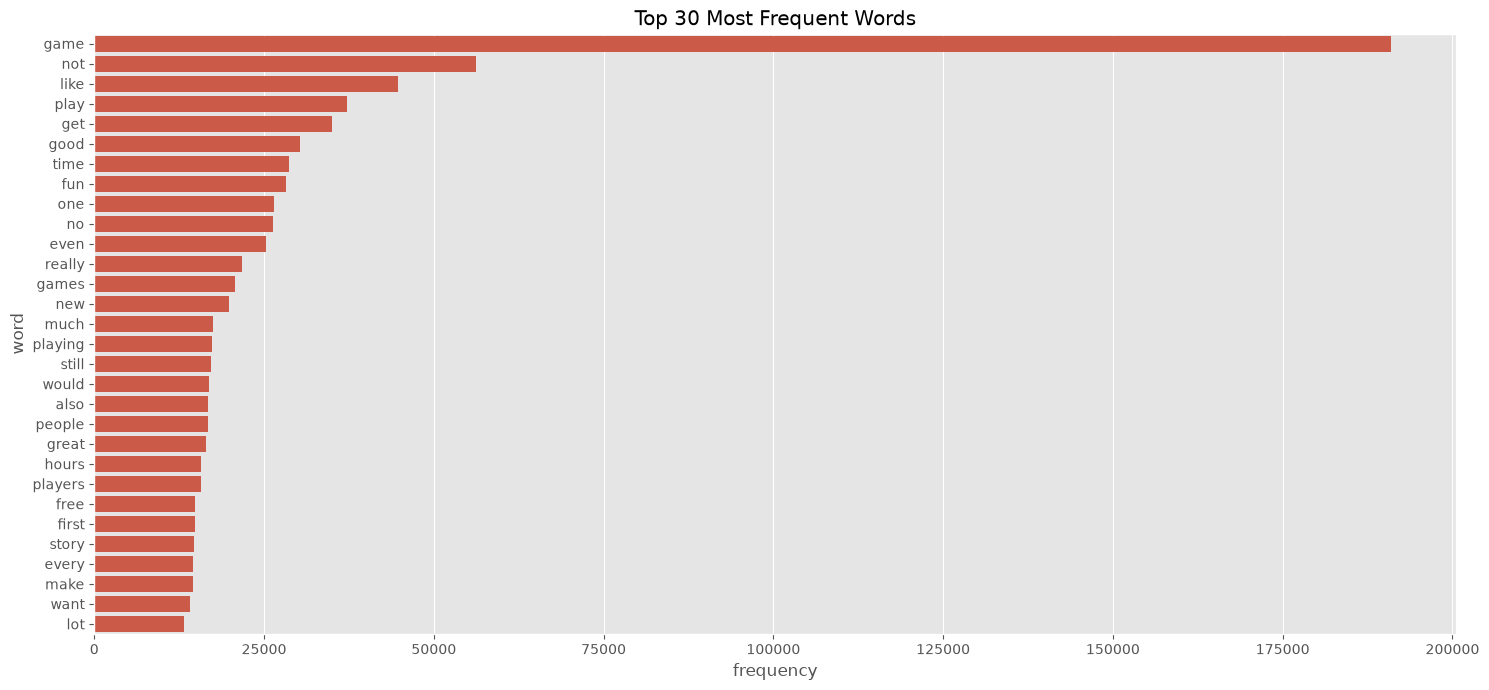

In [9]:
top_words = vocabulary_df.head(30)

plt.figure(figsize=(15,7))

sns.barplot(
    data=top_words,
    x="frequency",
    y="word"
)

plt.title("Top 30 Most Frequent Words")

plt.tight_layout()

plt.savefig(
    "outputs/figures/top30_words.png",
    dpi=300
)

plt.show()

## 6. TF-IDF representation

The cleaned reviews are converted into sparse numerical vectors using the TF-IDF weighting scheme.

In [10]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.90
)

tfidf_matrix = tfidf.fit_transform(
    df[text_column]
)

In [11]:
print(tfidf_matrix.shape)

(100175, 5000)


In [12]:
joblib.dump(
    tfidf,
    "outputs/embeddings/tfidf_vectorizer.pkl"
)

joblib.dump(
    tfidf_matrix,
    "outputs/embeddings/tfidf_matrix.pkl"
)

['outputs/embeddings/tfidf_matrix.pkl']

## 7. Word2Vec representation

Unlike TF-IDF, Word2Vec learns dense vector representations that capture semantic relationships between words.

The Skip-Gram architecture is selected because it generally performs better on semantic similarity tasks for medium-sized corpora.

In [13]:
word2vec_model = Word2Vec(
    sentences=documents,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    epochs=15,
    seed=SEED
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [14]:
word2vec_model.save(
    "outputs/embeddings/word2vec.model"
)

print("Word2Vec model saved successfully.")

Word2Vec model saved successfully.


## 8. Embedding statistics

In [15]:
embedding_stats = pd.DataFrame({

    "Metric":[
        "Vocabulary Size",
        "Embedding Dimension",
        "Context Window",
        "Epochs",
        "Minimum Word Frequency"
    ],

    "Value":[
        len(word2vec_model.wv),
        word2vec_model.vector_size,
        word2vec_model.window,
        word2vec_model.epochs,
        word2vec_model.min_count
    ]

})

embedding_stats

,Metric,Value
0,Vocabulary Size,22797
1,Embedding Dimension,100
2,Context Window,5
3,Epochs,15
4,Minimum Word Frequency,5


In [16]:
embedding_stats.to_csv(
    "outputs/tables/embedding_statistics.csv",
    index=False
)

## 9. Vocabulary inspection

In [17]:
vocabulary_size = len(word2vec_model.wv)

print(f"Vocabulary Size : {vocabulary_size:,}")

print()

print("First 30 Words")

print(word2vec_model.wv.index_to_key[:30])

Vocabulary Size : 22,797

First 30 Words
['game', 'not', 'like', 'play', 'get', 'good', 'time', 'fun', 'one', 'no', 'even', 'really', 'games', 'new', 'much', 'playing', 'still', 'would', 'also', 'people', 'great', 'hours', 'players', 'free', 'first', 'story', 'every', 'make', 'want', 'lot']


## 10. Most similar words

One requirement of the coursework is to retrieve the N most similar words from the learned corpus.

In [18]:
candidate_words = [

    "game",
    "player",
    "fun",
    "good",
    "bad",
    "story",
    "graphics",
    "multiplayer",
    "update",
    "steam"

]

In [19]:
similar_words = []

for word in candidate_words:

    if word not in word2vec_model.wv:

        continue

    neighbours = word2vec_model.wv.most_similar(
        word,
        topn=10
    )

    for neighbour, similarity in neighbours:

        similar_words.append({

            "Query Word": word,
            "Similar Word": neighbour,
            "Cosine Similarity": similarity

        })

similar_words_df = pd.DataFrame(similar_words)

display(similar_words_df.head(30))

,Query Word,Similar Word,Cosine Similarity
0,game,games,0.656613
1,game,honestly,0.645406
2,game,friendsi,0.642167
3,game,excepting,0.639048
4,game,exprience,0.638702
5,game,pontential,0.629534
6,game,experince,0.626038
7,game,really,0.618891
8,game,warfame,0.615011
9,game,however,0.612759


In [20]:
similar_words_df.to_csv(

    "outputs/tables/similar_words.csv",

    index=False

)

## 11. Semantic-similarity examples

In [21]:
queries = [

    "game",
    "player",
    "story",
    "graphics"

]

for query in queries:

    if query not in word2vec_model.wv:

        continue

    print("=" * 70)

    print(query.upper())

    print()

    neighbours = word2vec_model.wv.most_similar(

        query,

        topn=10

    )

    for word, similarity in neighbours:

        print(f"{word:20} {similarity:.4f}")

    print()

GAME

games                0.6566
honestly             0.6454
friendsi             0.6422
excepting            0.6390
exprience            0.6387
pontential           0.6295
experince            0.6260
really               0.6189
warfame              0.6150
however              0.6128

PLAYER

players              0.7311
base                 0.5565
gamer                0.5504
playerbase           0.5479
matchup              0.5397
alienating           0.5312
soley                0.5289
brainlessly          0.5267
playerbases          0.5232
freelance            0.5130

STORY

storyline            0.8219
plot                 0.7542
lore                 0.7363
narrative            0.6883
stories              0.6718
storytelling         0.6409
voiceacting          0.6365
cinematics           0.6321
intriguing           0.6229
compelling           0.6182

GRAPHICS

graphic              0.8342
visuals              0.8274
gfx                  0.7406
beautiful            0.7163
looks         

## 12. Word-vector example

Each word is represented as a dense numerical vector in a 100-dimensional embedding space.

In [22]:
example_word = "game"

if example_word in word2vec_model.wv:

    vector = word2vec_model.wv[example_word]

    print(vector.shape)

    print()

    print(vector[:20])

(100,)

[ 0.16602035 -0.0515088  -0.18872409  0.05882653 -0.29801607 -0.05847927
 -0.45512104  0.10360909 -0.0493621  -0.12390109 -0.04000233  0.05511666
  0.3820326   0.14699726 -0.3297616  -0.15464456  0.04245573 -0.15340494
  0.16496152 -0.15900917]


## 13. Cosine-similarity matrix

In [23]:
selected_words = [

    word

    for word in [

        "game",
        "player",
        "graphics",
        "story",
        "steam",
        "fun",
        "good",
        "bad"

    ]

    if word in word2vec_model.wv

]

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

vectors = np.array([

    word2vec_model.wv[word]

    for word in selected_words

])

similarity_matrix = cosine_similarity(vectors)

similarity_df = pd.DataFrame(

    similarity_matrix,

    index=selected_words,

    columns=selected_words

)

display(similarity_df.round(3))

,game,player,graphics,story,steam,fun,good,bad
game,1.000,0.342,0.428,0.499,0.428,0.575,0.471,0.378
player,0.342,1.000,0.160,0.262,0.164,0.261,0.180,0.157
graphics,0.428,0.160,1.000,0.407,0.182,0.360,0.511,0.463
story,0.499,0.262,0.407,1.000,0.149,0.314,0.391,0.344
steam,0.428,0.164,0.182,0.149,1.000,0.209,0.191,0.163
fun,0.575,0.261,0.360,0.314,0.209,1.000,0.598,0.358
good,0.471,0.180,0.511,0.391,0.191,0.598,1.000,0.764
bad,0.378,0.157,0.463,0.344,0.163,0.358,0.764,1.000


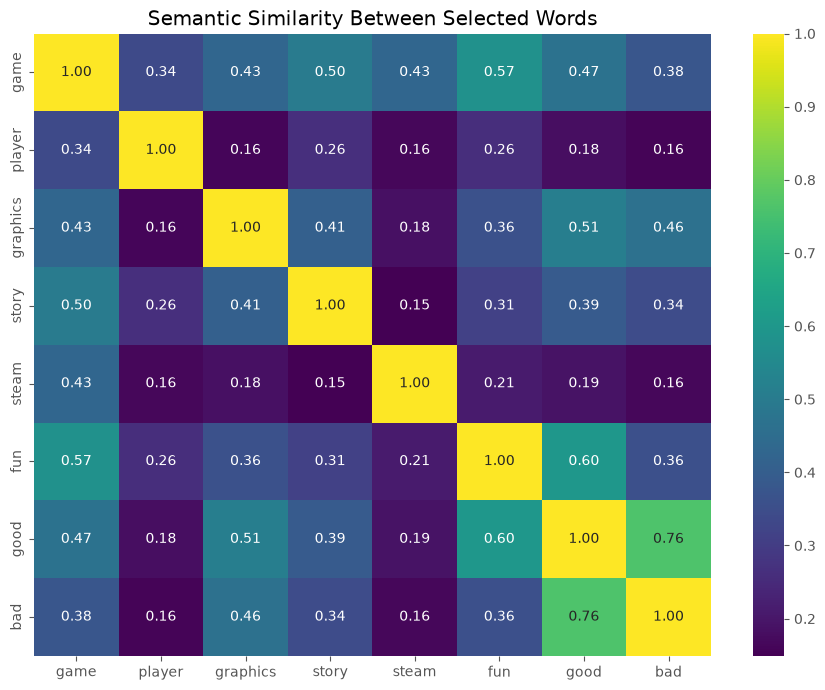

In [25]:
plt.figure(figsize=(9,7))

sns.heatmap(

    similarity_df,

    annot=True,

    cmap="viridis",

    fmt=".2f"

)

plt.title(

    "Semantic Similarity Between Selected Words"

)

plt.tight_layout()

plt.savefig(

    "outputs/figures/semantic_similarity_heatmap.png",

    dpi=300

)

plt.show()

## 14. PCA projection of word embeddings

Principal Component Analysis (PCA) is used to reduce the dimensionality of the learned Word2Vec embeddings while preserving as much variance as possible.

In [26]:
top_n = 300

available_words = word2vec_model.wv.index_to_key[:top_n]

embedding_vectors = np.array(
    [word2vec_model.wv[word] for word in available_words]
)

pca = PCA(
    n_components=2,
    random_state=SEED
)

pca_embeddings = pca.fit_transform(
    embedding_vectors
)

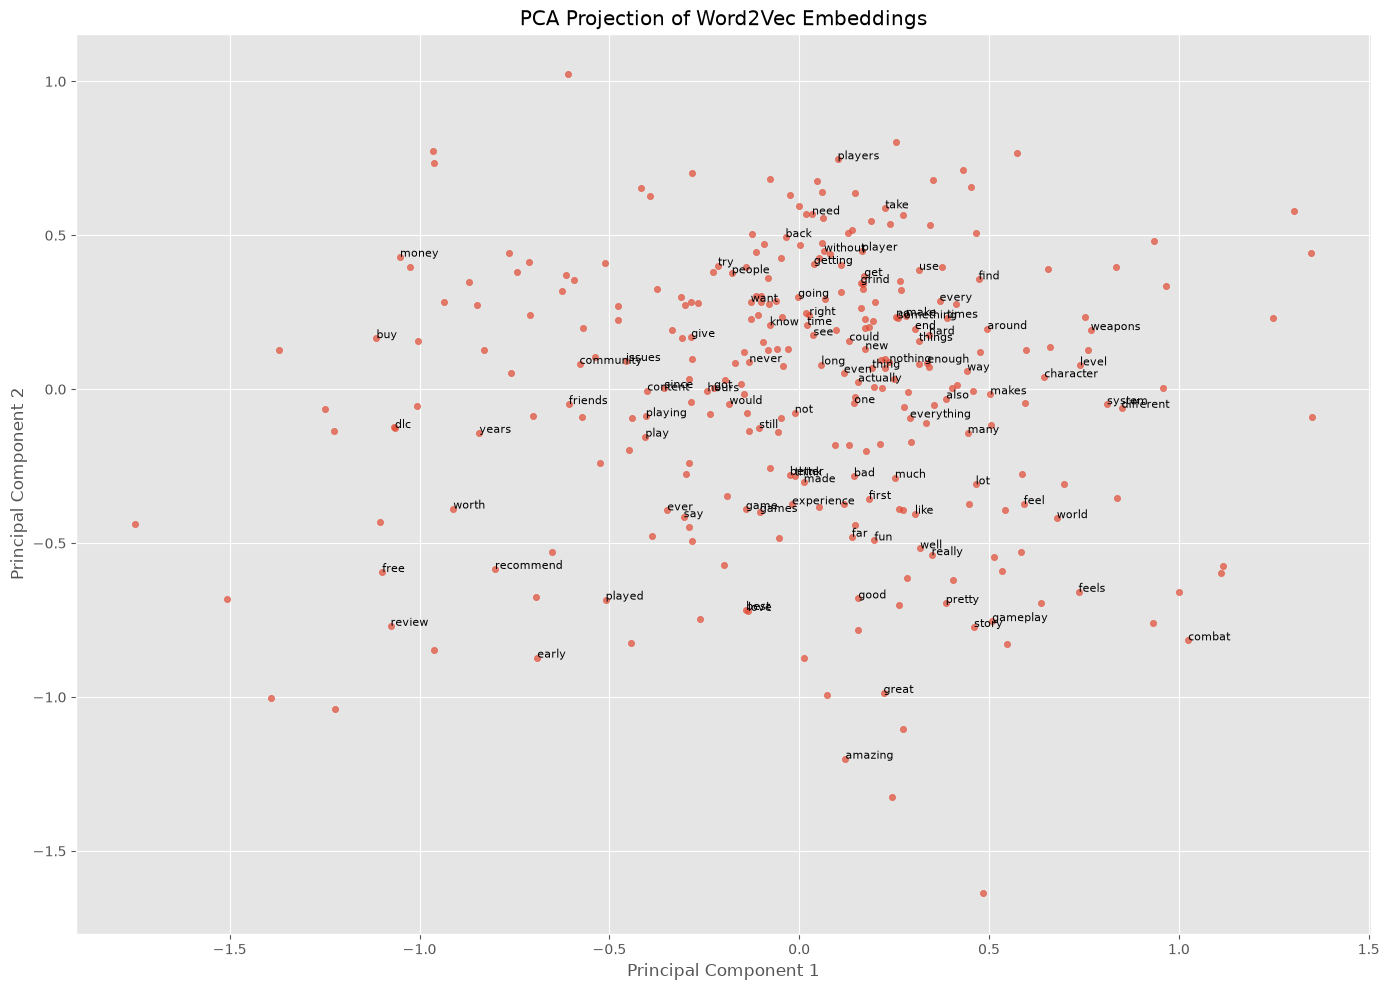

In [27]:
plt.figure(figsize=(14,10))

plt.scatter(
    pca_embeddings[:,0],
    pca_embeddings[:,1],
    s=20,
    alpha=0.7
)

for i, word in enumerate(available_words[:100]):

    plt.text(
        pca_embeddings[i,0],
        pca_embeddings[i,1],
        word,
        fontsize=8
    )

plt.title("PCA Projection of Word2Vec Embeddings")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.tight_layout()

plt.savefig(
    "outputs/figures/pca_embeddings.png",
    dpi=300
)

plt.show()

## 15. t-SNE projection of word embeddings

t-SNE is applied to visualize local semantic neighbourhoods within the embedding space.

In [28]:
tsne = TSNE(

    n_components=2,

    perplexity=30,

    learning_rate="auto",

    init="pca",

    random_state=SEED

)

tsne_embeddings = tsne.fit_transform(
    embedding_vectors
)

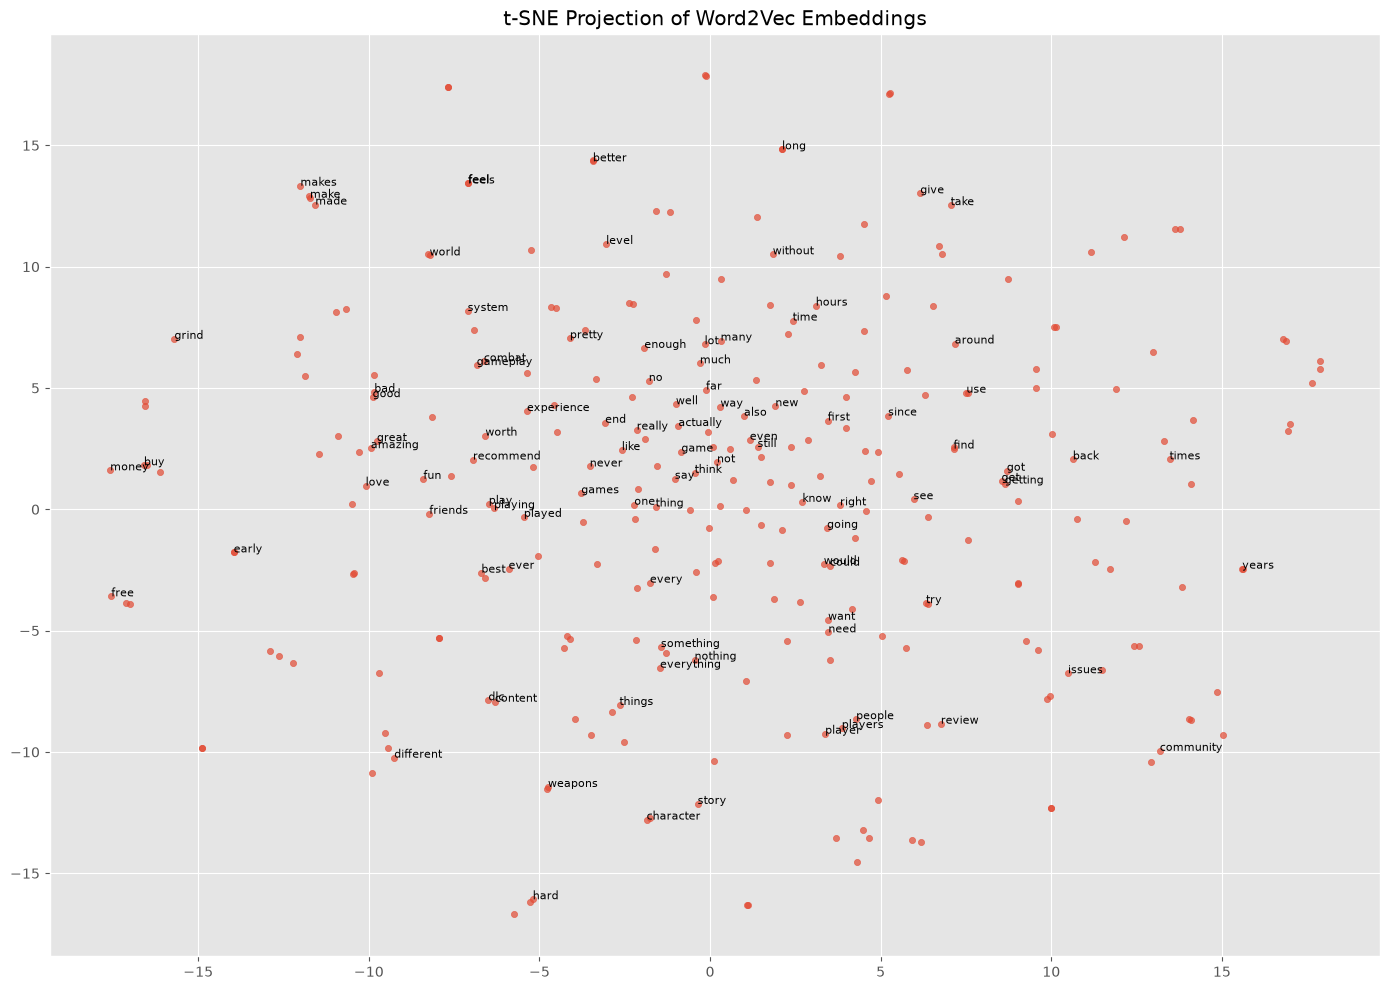

In [29]:
plt.figure(figsize=(14,10))

plt.scatter(

    tsne_embeddings[:,0],

    tsne_embeddings[:,1],

    s=20,

    alpha=0.7

)

for i, word in enumerate(available_words[:100]):

    plt.text(

        tsne_embeddings[i,0],

        tsne_embeddings[i,1],

        word,

        fontsize=8

    )

plt.title("t-SNE Projection of Word2Vec Embeddings")

plt.tight_layout()

plt.savefig(

    "outputs/figures/tsne_embeddings.png",

    dpi=300

)

plt.show()

## 16. Positive and negative vocabulary

In [30]:
label_column = "target"

In [31]:
positive_reviews = df[df["target"] == 1]

negative_reviews = df[df["target"] == 0]

print(f"Positive reviews: {len(positive_reviews):,}")
print(f"Negative reviews: {len(negative_reviews):,}")

Positive reviews: 64,825
Negative reviews: 35,350


In [32]:
positive_counter = Counter(
    " ".join(
        positive_reviews["clean_review"]
    ).split()
)

negative_counter = Counter(
    " ".join(
        negative_reviews["clean_review"]
    ).split()
)

In [33]:
positive_df = pd.DataFrame(
    positive_counter.most_common(20),
    columns=["Word", "Frequency"]
)

negative_df = pd.DataFrame(
    negative_counter.most_common(20),
    columns=["Word", "Frequency"]
)

display(positive_df)
display(negative_df)

,Word,Frequency
0,game,107894
1,not,27453
2,like,26337
3,play,20462
4,good,20441
5,fun,18735
6,get,18562
7,one,15855
8,time,15503
9,really,13644


,Word,Frequency
0,game,83095
1,not,28698
2,like,18439
3,play,16774
4,get,16481
5,no,14627
6,even,14020
7,time,13126
8,one,10610
9,good,9921


## 17. Positive and negative vocabulary visualisation

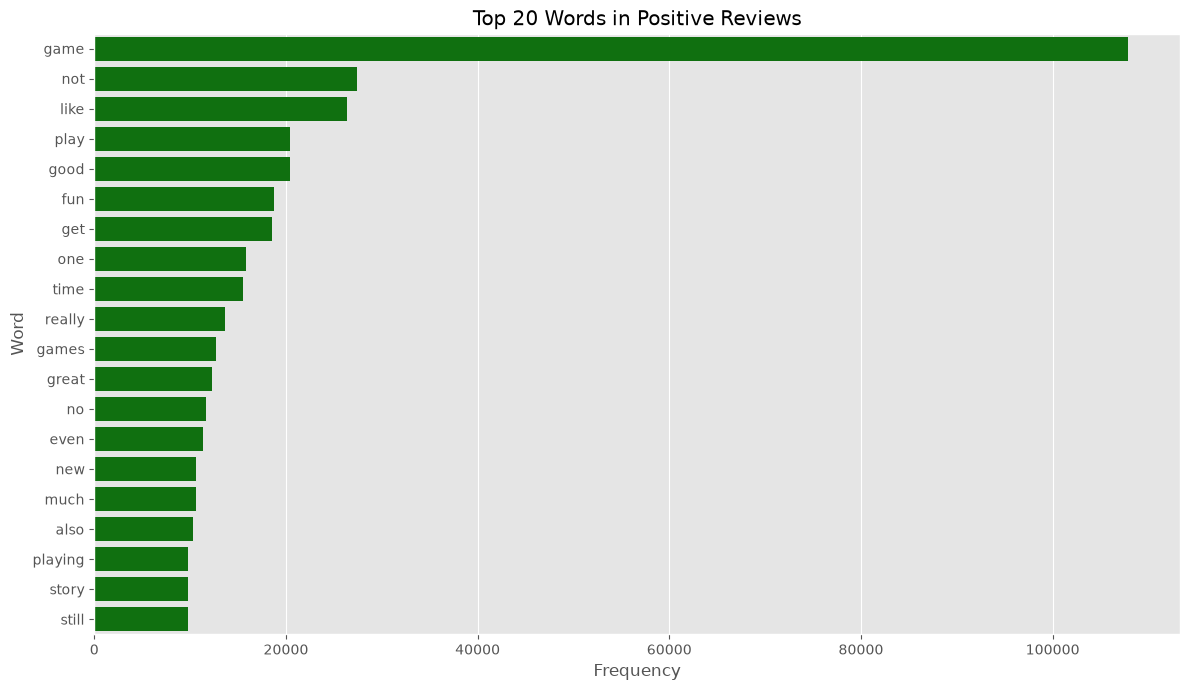

In [34]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=positive_df,
    x="Frequency",
    y="Word",
    color="green"
)

plt.title("Top 20 Words in Positive Reviews")

plt.tight_layout()

plt.savefig(
    "outputs/figures/top_positive_words.png",
    dpi=300
)

plt.show()

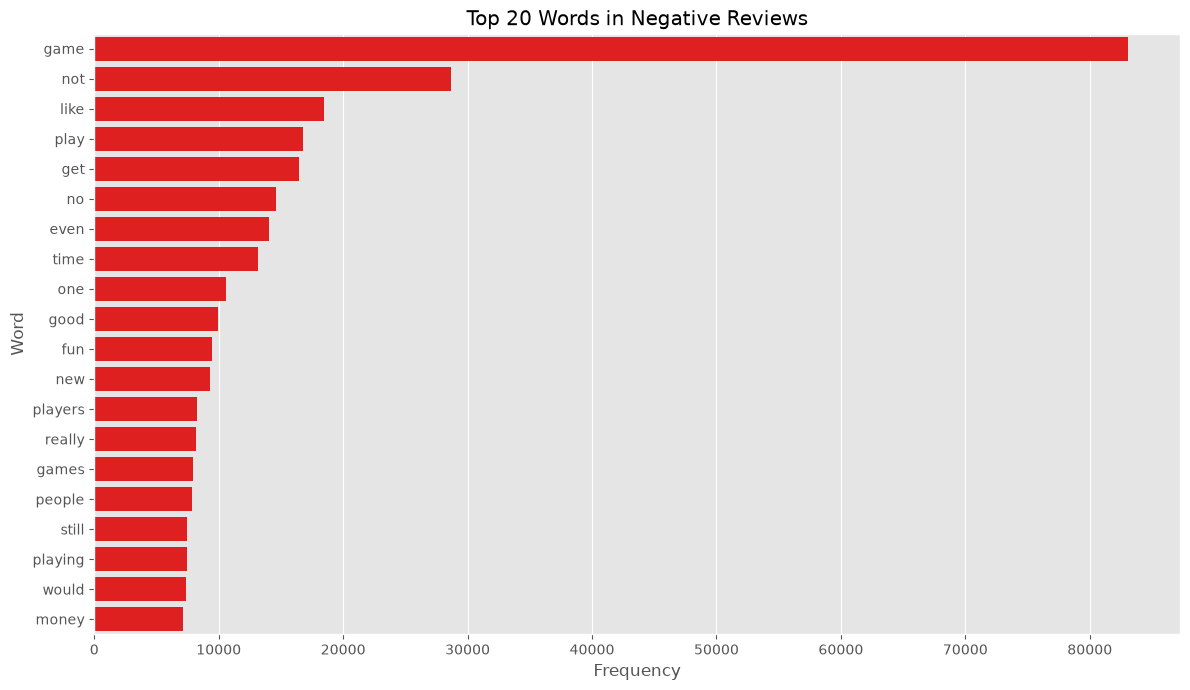

In [35]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=negative_df,
    x="Frequency",
    y="Word",
    color="red"
)

plt.title("Top 20 Words in Negative Reviews")

plt.tight_layout()

plt.savefig(
    "outputs/figures/top_negative_words.png",
    dpi=300
)

plt.show()

## 18. Export tables and figures

In [36]:
positive_df.to_csv(
    "outputs/tables/top_positive_words.csv",
    index=False
)

negative_df.to_csv(
    "outputs/tables/top_negative_words.csv",
    index=False
)

similar_words_df.to_csv(
    "outputs/tables/similar_words.csv",
    index=False
)

embedding_stats.to_csv(
    "outputs/tables/embedding_statistics.csv",
    index=False
)

vocabulary_df.to_csv(
    "outputs/tables/vocabulary_statistics.csv",
    index=False
)

## Takeaways

The notebook generated both sparse (TF-IDF) and dense (Word2Vec) text representations. The semantic relationships between words were explored using similarity queries, while PCA and t-SNE were employed to visualize the embedding space. Finally, the vocabulary of positive and negative reviews was analysed separately and all artefacts were exported for use in the following notebooks.